In [1]:
import numpy as np
import pandas as pd
import os

folder_path = os.getcwd()
dataset_folder_path_raw = os.path.join(folder_path,"..\\data_raw\\")
dataset_folder_path_clean = os.path.join(folder_path,"..\\data_cleaned\\")

## Customers EDA

In [2]:
customer_dataset_folder = os.path.join(dataset_folder_path_raw,'customers_dataset.csv')
customer_df = pd.read_csv(customer_dataset_folder)
customer_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [3]:
# Number of unique customers agains customer records
unique_customers = customer_df['customer_unique_id'].nunique()
total_customers_records  = customer_df['customer_id'].count()
unique_customers = (unique_customers / total_customers_records)*100
print(unique_customers)

96.63619633752677


In [4]:
# Here we are trying to understand the number of locations  that cover the max number of customers
for col in ['customer_zip_code_prefix','customer_city','customer_state']:
    # Unique customers per location (better metric)
    counts = customer_df.groupby(col)['customer_unique_id'].nunique()

    # Sort descending
    counts = counts.sort_values(ascending=False)

    # Convert to percentage
    percentage = counts / counts.sum()

    # Cumulative percentage
    cumulative_percentage = percentage.cumsum()

    # Number of locations needed for 80%
    locations_needed = (cumulative_percentage < 0.80).sum() + 1

    print(f"\nColumn: {col}")
    print(f"Total unique locations: {len(counts)}")
    print(f"Number of {col} needed to cover 80% of customers: {locations_needed}")
    if col=='customer_state':
        print(counts.head(locations_needed))


Column: customer_zip_code_prefix
Total unique locations: 14994
Number of customer_zip_code_prefix needed to cover 80% of customers: 6372

Column: customer_city
Total unique locations: 4119
Number of customer_city needed to cover 80% of customers: 356

Column: customer_state
Total unique locations: 27
Number of customer_state needed to cover 80% of customers: 6
customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
Name: customer_unique_id, dtype: int64


###  Here 6 states occupy 80% of customers

### Finding repeated customers

In [5]:
# Count how many times each unique customer appears
customer_counts = (
    customer_df.groupby('customer_unique_id').size().reset_index(name='purchase_count')
)

# Keep only repeated customers
repeat_customers = customer_counts[customer_counts['purchase_count'] > 1]

repeat_customers.sort_values(by='purchase_count',ascending=False)


,customer_unique_id,purchase_count
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
...,...,...
634,01a22e2079ea71e17313b88e5811e54a,2
681,01c289bb06354cdc7e6549570f20ada4,2
726,01ea7dfdac01a4e8fbe2902b73510b20,2
740,01f2285f85a1c603eb7ef755ad311769,2


In [6]:
# Merge back with original dataframe to get location info
repeat_df = customer_df.merge(
    repeat_customers[['customer_unique_id']],
    on='customer_unique_id',
    how='inner'
)


repeated_places = (
#     repeat_df.groupby(['customer_state', 'customer_city'])['customer_unique_id']
    repeat_df.groupby(['customer_state'])['customer_unique_id']
    .nunique()
    .reset_index(name='repeat_customer_count')
    .sort_values(by='repeat_customer_count', ascending=False)
)

print(repeated_places.head())


   customer_state  repeat_customer_count
25             SP                   1313
18             RJ                    429
10             MG                    348
22             RS                    169
17             PR                    149


In [7]:
# Sort by highest repeat customers
repeated_places = repeated_places.sort_values(
    by='repeat_customer_count',
    ascending=False
)

# Calculate cumulative percentage
total_repeat_customers = repeated_places['repeat_customer_count'].sum()

repeated_places['cumulative_customers'] = (
    repeated_places['repeat_customer_count'].cumsum()
)

repeated_places['cumulative_percentage'] = (
    repeated_places['cumulative_customers'] / total_repeat_customers * 100
)

# Places contributing to 80% repeated customers
top_80_places = repeated_places[
    repeated_places['cumulative_percentage'] <= 80
]

# Number of places
num_places = len(top_80_places)

print(f"80% of repeated customers come from {num_places} places")

# Show those places
print(top_80_places[['customer_state', 'repeat_customer_count', 'cumulative_percentage']])

80% of repeated customers come from 5 places
   customer_state  repeat_customer_count  cumulative_percentage
25             SP                   1313              43.233454
18             RJ                    429              57.359236
10             MG                    348              68.817912
22             RS                    169              74.382614
17             PR                    149              79.288772


##                                  ORDERS EDA

In [8]:
orders_dataset_path = os.path.join(dataset_folder_path_clean,'orders_dataset.csv')
orders_df = pd.read_csv(orders_dataset_path)
orders_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18


In [9]:
orders_df.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [ ]:
# Irrespective of whether we have converted the columns to date time or not if we store data in csv it will get back to string even if we store in date time format
for col in ('order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date'):
    orders_df[col] = pd.to_datetime(orders_df[col],errors='coerce')

### Univariate Analysis of orders
    * Orders per month(Monthly Order volume)
    * Orders per day
    * Delivery duration distribution

In [11]:
# # Convert the timestamp column to datetime
# orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# --- Orders per month ---
# Extract year-month from timestamp
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')
orders_per_month = orders_df.groupby('year_month')['order_id'].count().reset_index()
orders_per_month.rename(columns={'order_id': 'orders_count'}, inplace=True)
print("Orders per month:")
print(orders_per_month)

# --- Orders per day ---
# Extract date only
orders_df['order_date'] = orders_df['order_purchase_timestamp'].dt.date
orders_per_day = orders_df.groupby('order_date')['order_id'].count().reset_index()
orders_per_day.rename(columns={'order_id': 'orders_count'}, inplace=True)
print("\nOrders per day:")
print(orders_per_day)

Orders per month:
   year_month  orders_count
0     2016-09             4
1     2016-10           324
2     2016-12             1
3     2017-01           800
4     2017-02          1780
5     2017-03          2682
6     2017-04          2404
7     2017-05          3700
8     2017-06          3245
9     2017-07          4026
10    2017-08          4331
11    2017-09          4285
12    2017-10          4631
13    2017-11          7544
14    2017-12          5673
15    2018-01          7269
16    2018-02          6728
17    2018-03          7211
18    2018-04          6939
19    2018-05          6873
20    2018-06          6167
21    2018-07          6292
22    2018-08          6512
23    2018-09            16
24    2018-10             4

Orders per day:
     order_date  orders_count
0    2016-09-04             1
1    2016-09-05             1
2    2016-09-13             1
3    2016-09-15             1
4    2016-10-02             1
..          ...           ...
629  2018-09-29            

count    72751.000000
mean        12.083504
std          9.487659
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_duration, dtype: float64


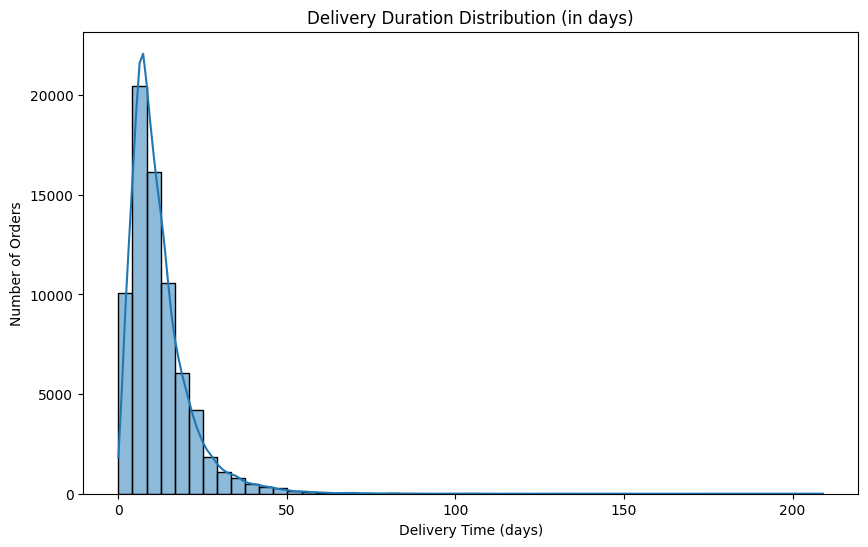

In [12]:
# Delivery duration distribution
import matplotlib.pyplot as plt
import seaborn as sns


# Convert to datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'],errors='co')
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'],errors='coerce')

# Remove rows where delivery date is missing
df = orders_df.dropna(subset=['order_delivered_customer_date'])

# Calculate delivery duration in days
df['delivery_duration'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Basic stats
print(df['delivery_duration'].describe())

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_duration'], bins=50, kde=True)

plt.title('Delivery Duration Distribution (in days)')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Number of Orders')
plt.show()

### Bivariate of order details
    * Status vs delivery duration
    * Month vs order volume


### Statewise delivery duration

In [13]:
# Merge orders with customers to get state
df = orders_df.merge(customer_df, on='customer_id', how='left')

# Calculate delivery duration (in days)
df['delivery_duration'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Remove invalid values
df = df[df['delivery_duration'] >= 0]

# Group by state
state_delivery = df.groupby('customer_state')['delivery_duration'].mean().reset_index()

# Sort by delivery time
state_delivery = state_delivery.sort_values(by='delivery_duration', ascending=False)

print(df)

                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
87495  0d2b97cf9a17b4e44a12371fa7536c1c  a10f809da5724187f9886fb340997c50   
87496  425db79ac88bce97ec9884db3be0e019  9446e9602579c66ccea1df94a8e1dcfa   
87497  07f6b1ad9ba4f7a4d2326adf7b8f517f  0cd47abbc8d9c815ff586e5b21280105   
87498  ea1e1ffc5007718537ed671406b8538d  2db1a414c23fd5195a1a90da12cd28c5   
87499  fef460386535d68be40b5323a195b4b1  9f91a746be44192dc25de0c87d35e0c6   

      order_status order_purchase_timestamp   order_approved_at  \
0       

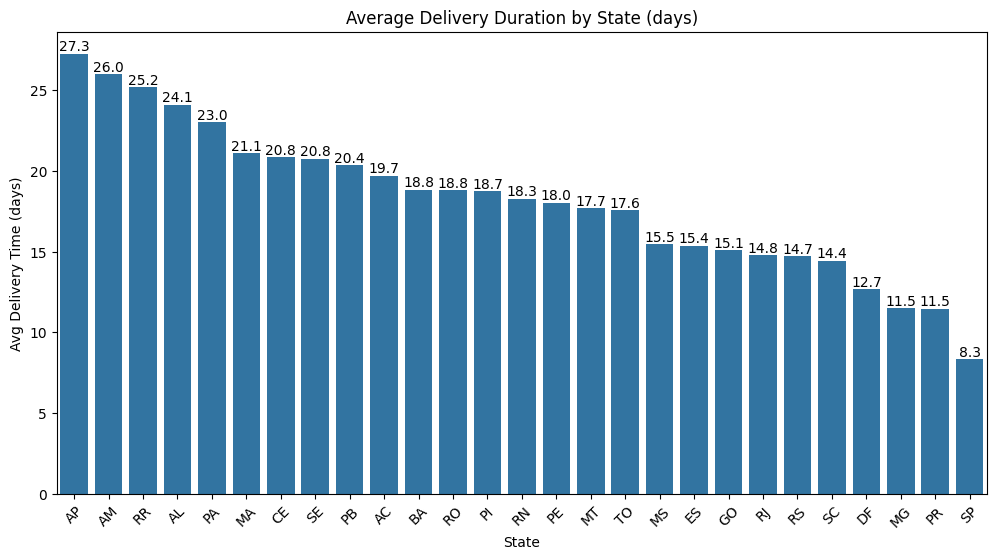

In [69]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=state_delivery, x='customer_state', y='delivery_duration')

plt.title('Average Delivery Duration by State (days)')
plt.xlabel('State')
plt.ylabel('Avg Delivery Time (days)')
plt.xticks(rotation=45)

# Add values on bars
ax.bar_label(ax.containers[0], fmt='%.1f')

plt.show()

###  Feature Engineering Ideas
    * delivery_days
    * approval_delay
    * estimated_vs_actual_days



In [35]:
# Delivery time
avg_delivery_duration = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days.mean()
avg_delivery_duration

np.float64(12.083504006817776)

In [44]:
## Approval delay
avg_approval_delay = (orders_df['order_approved_at'] - orders_df['order_purchase_timestamp']).dt.days.mean()
avg_approval_delay

np.float64(0.2693657545680353)

In [50]:
# Avg difference b/n estimated and actual delivery distribution
estimation_acutal_diff = ( orders_df['order_estimated_delivery_date']  - orders_df['order_delivered_customer_date']).dt.days.median()
estimation_acutal_diff

np.float64(11.0)

###  Interesting Checks
    * Extremely delayed deliveries
    * Cancelled orders trend


In [53]:
# Extremely delayed deliveries
# Step 1:  Calculate delivery duration
df['delivery_duration'] = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days

# Step 2: Compute mean and standard deviation
mean_duration = df['delivery_duration'].mean()
std_duration = df['delivery_duration'].std()

# Step 3: Calculating Z-scores
df['delivery_zscore'] = (df['delivery_duration'] - mean_duration) / std_duration

# Step 4: Identify extremely delayed orders
extreme_delays = df[df['delivery_zscore'] > 3]

print(f"Total orders: {len(df)}")
print(f"Extreme delays (>3σ): {len(extreme_delays)}")
print(f"Percentage: {100*len(extreme_delays)/len(df):.2f}%")

Total orders: 72747
Extreme delays (>3σ): 1193
Percentage: 1.64%


In [54]:
# Cancellation trend

total_orders = orders_df.shape[0]
cancelled_orders = len(orders_df[orders_df['order_status'] == 'canceled'])

cancellation_rate = cancelled_orders / total_orders * 100

print(f"Total Orders: {total_orders}")
print(f"Cancelled Orders: {cancelled_orders}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Total Orders: 99441
Cancelled Orders: 625
Cancellation Rate: 0.63%


In [58]:
# Estimating average estimated delivery days for cancelled orders
cancelled_order_deliveries = orders_df[orders_df['order_status']=='canceled']
avg_delivery_time = (cancelled_order_deliveries['order_estimated_delivery_date'] - cancelled_order_deliveries['order_purchase_timestamp']).dt.days.mean()

avg_delivery_time

np.float64(22.2768)

### Order Items Dataset EDA


In [60]:
order_items_dataset = os.path.join(dataset_folder_path_clean,"order_items_dataset.csv")
order_items_df = pd.read_csv(order_items_dataset)
order_items_df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

###  Univariate Analysis
    * Product price distribution
    * Freight distribution
    * Items per order


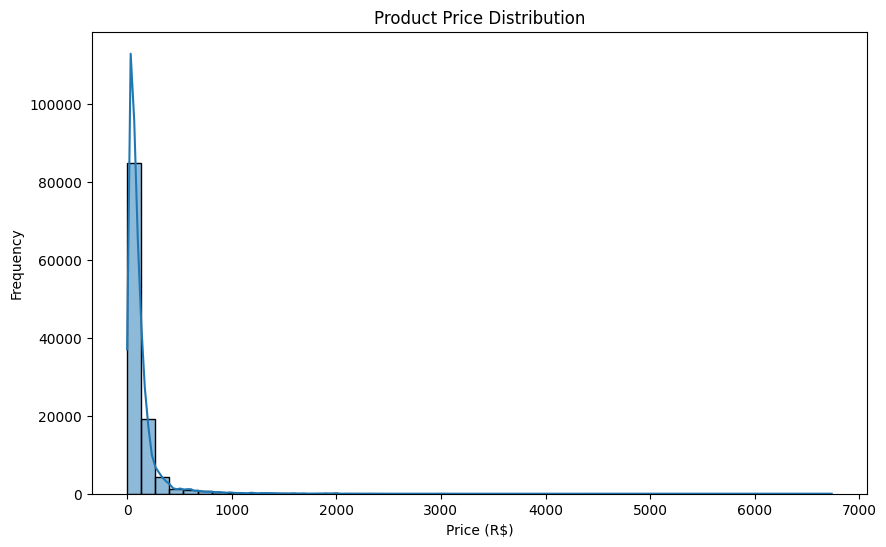

In [61]:
# Product price distribution

plt.figure(figsize=(10,6))
sns.histplot(order_items_df['price'], bins=50, kde=True)

plt.title('Product Price Distribution')
plt.xlabel('Price (R$)')
plt.ylabel('Frequency')
plt.show()

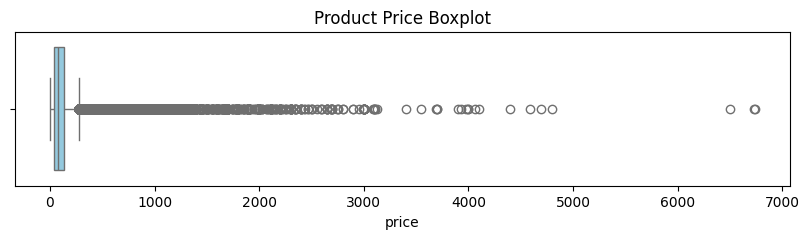

In [63]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=order_items_df['price'],
    color='skyblue'
)

plt.title('Product Price Boxplot')
plt.show()

In [62]:
p99 = order_items_df['price'].quantile(0.99)

high_price_items = order_items_df[ order_items_df['price'] > p99]

print(f"99th percentile price: {p99:.2f}")
print(f"Number of outliers: {len(high_price_items)}")

99th percentile price: 890.00
Number of outliers: 1117


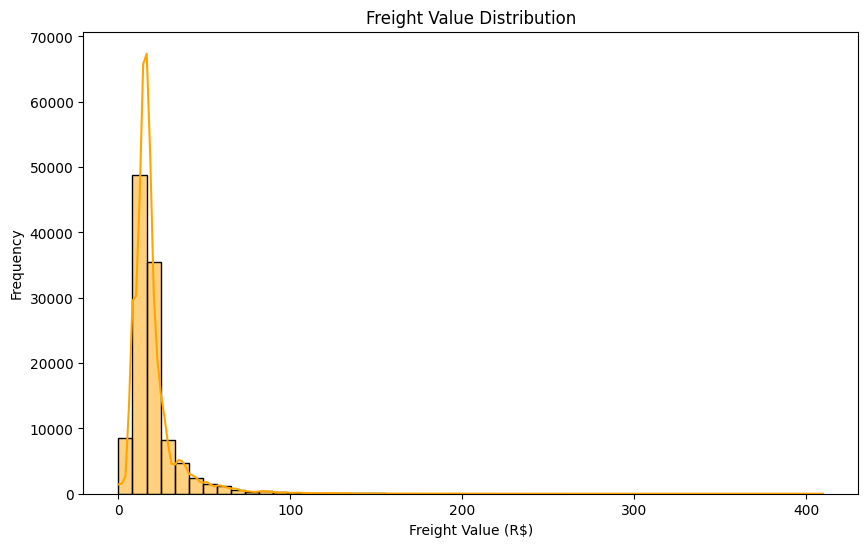

In [64]:
# Freight value distribution
plt.figure(figsize=(10,6))

sns.histplot(
    order_items_df['freight_value'],
    bins=50,
    kde=True,
    color='orange'
)

plt.title('Freight Value Distribution')
plt.xlabel('Freight Value (R$)')
plt.ylabel('Frequency')
plt.show()

In [70]:
# Items per order

# Items per order
items_per_order = (
    order_items_df.groupby('order_id').size().reset_index(name='num_items')
)

# Frequency table (values behind the bars)
freq_table = (
    items_per_order['num_items']
    .value_counts()
    .sort_index()
    .reset_index()
)

freq_table.columns = ['num_items', 'order_count']

print(freq_table)

    num_items  order_count
0           1        88863
1           2         7516
2           3         1322
3           4          505
4           5          204
5           6          198
6           7           22
7           8            8
8           9            3
9          10            8
10         11            4
11         12            5
12         13            1
13         14            2
14         15            2
15         20            2
16         21            1


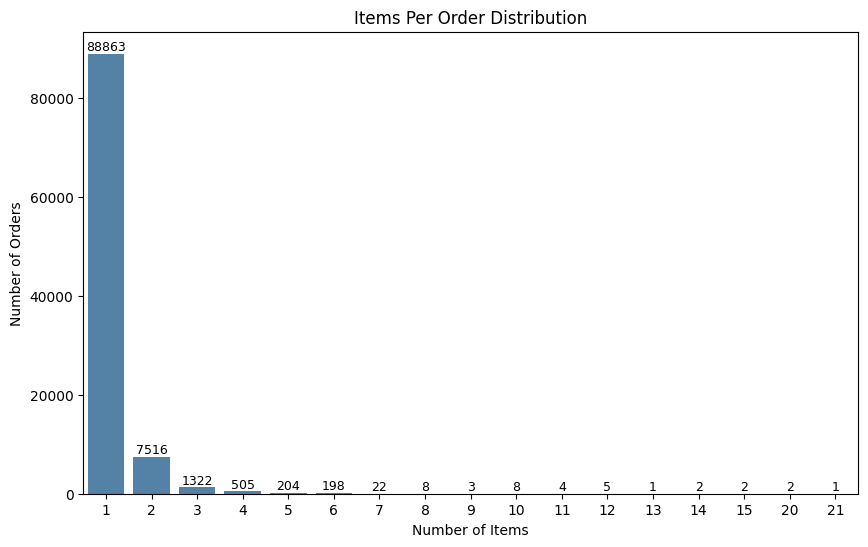

In [71]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=freq_table,
    x='num_items',
    y='order_count',
    color='steelblue'
)

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Items Per Order Distribution')
plt.xlabel('Number of Items')
plt.ylabel('Number of Orders')

plt.show()

### Bivariate Analysis
    * Price vs freight

### Interesting Checks
    * Outlier products
    * Very high freight charges

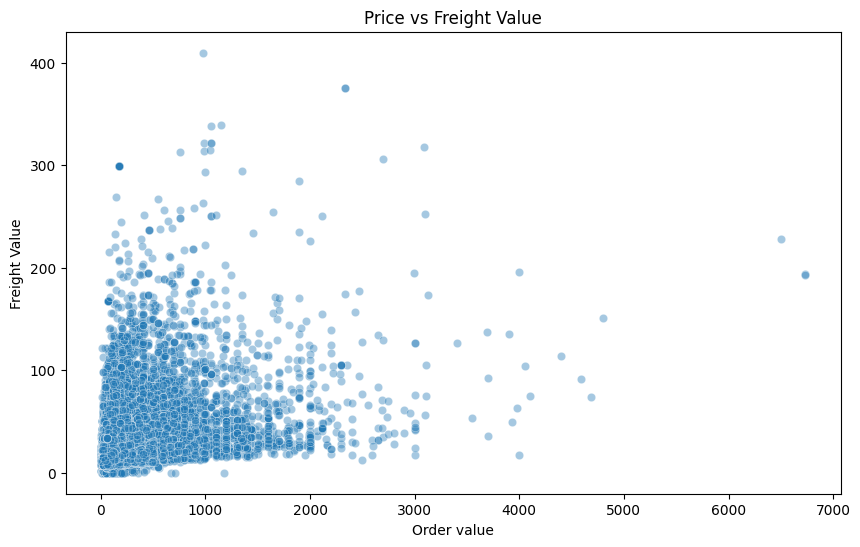

In [75]:
# Finding price vs freight
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=order_items_df,
    x='price',
    y='freight_value',
    alpha=0.4
)

plt.title('Price vs Freight Value')
plt.xlabel('Order value')
plt.ylabel('Freight Value')

plt.show()

In [76]:
# Very high freight charges
p99 = order_items_df['freight_value'].quantile(0.99)

high_price_items = order_items_df[ order_items_df['freight_value'] > p99]

print(f"99th percentile freight price: {p99:.2f}")
print(f"Number of outliers: {len(high_price_items)}")

99th percentile freight price: 84.52
Number of outliers: 1124


### Finding order items & its details
* Finding from which state more orders are placed
* Finding average approval,carrier_
* delivery and customer_delivery time
* Finding which products are being ordered more in quanitity
* Top repeating product orders
* Avg order size and quantity
* Finding success rate and failure rate

### 1. Finding from which state more orders are placed


In [15]:
# Merge orders with customer information
orders_customers = orders_df.merge(
    customer_df,
    on='customer_id',
    how='left'
)

# Count orders by city
state_order_counts = (
    orders_customers
    .groupby('customer_state')
    .size()
    .reset_index(name='order_count')
    .sort_values('order_count', ascending=False)
)

state_order_counts.head()

,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045


In [16]:
# Finding which states occupy up to 80% of orders
# Calculate cumulative percentage
total_orders = state_order_counts['order_count'].sum()

state_order_counts['cum_orders'] = state_order_counts['order_count'].cumsum()

state_order_counts['cum_pct'] = (state_order_counts['cum_orders'] / total_orders * 100)

state_order_counts[state_order_counts['cum_pct']<=80]

,customer_state,order_count,cum_orders,cum_pct
25,SP,41746,41746,41.980672
18,RJ,12852,54598,54.904918
10,MG,11635,66233,66.605324
22,RS,5466,71699,72.102050
17,PR,5045,76744,77.175411


In [17]:
# Finding customers who are placing orders repeatedly

orders_count = (
    orders_customers
    .groupby('customer_unique_id')['order_id']
    .size()
    .reset_index(name='order_count')
    .sort_values('order_count', ascending=False)
)

repeated_customers = orders_count[orders_count['order_count']>1]

repeated_customers.shape

(2997, 2)

In [18]:
# % of customers repeaeting to place orders
total_customers = orders_customers['customer_unique_id'].nunique()

repeat_pct = repeated_customers['customer_unique_id'].nunique() / total_customers * 100


print(f"{repeat_pct:.2f}%")

3.12%


In [19]:
#  Finding states from where more repeated customers are coming
repeat_customer_states = (
    orders_customers[orders_customers['customer_unique_id'].isin(repeated_customers['customer_unique_id'])]
    .groupby('customer_state')['customer_unique_id']
    .nunique()
    .reset_index(name='repeat_customers')
    .sort_values('repeat_customers', ascending=False)
)

repeat_customer_states.head()

,customer_state,repeat_customers
25,SP,1313
18,RJ,429
10,MG,348
22,RS,169
17,PR,149


###  2. Finding average  approval,carrier_delivery and customer_delivery time


In [20]:
orders_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
year_month                            period[M]
order_date                               object
dtype: object

In [59]:
# Calculate durations
orders_df['approval_time'] = (orders_df['order_approved_at'] - orders_df['order_purchase_timestamp']).dt.total_seconds() / 3600  # hours

orders_df['carrier_delivery_time'] = ( orders_df['order_delivered_carrier_date'] - orders_df['order_approved_at']).dt.total_seconds() / 3600  # hours

orders_df['customer_delivery_time'] = (orders_df['order_delivered_customer_date'] - orders_df['order_delivered_carrier_date']).dt.total_seconds() / 3600  # hours

# Average times
avg_approval = orders_df['approval_time'].mean()
avg_carrier_delivery = orders_df['carrier_delivery_time'].mean()
avg_customer_delivery = orders_df['customer_delivery_time'].mean()

print(f"Average Approval Time: {avg_approval:.2f} hours")
print(f"Average Carrier Delivery Time: {avg_carrier_delivery:.2f} hours")
print(f"Average Customer Delivery Time: {avg_customer_delivery:.2f} hours")

Average Approval Time: 10.40 hours
Average Carrier Delivery Time: 67.52 hours
Average Customer Delivery Time: 223.54 hours


### 3. Finding success rate and failure rate

In [22]:
total_orders = orders_df.shape[0]
statuses_pct = (orders_df['order_status'].value_counts() / total_orders)*100
statuses_pct

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: count, dtype: float64

### 4. Finding which products are being ordered more in quanitity

In [24]:
product_quantity = (
    order_items_df.groupby('product_id')['order_item_id']
    .count()
    .reset_index(name='quantity_sold')
    .sort_values('quantity_sold', ascending=False)
)

# Findinng how many products cater 80% of orders
total_quantity = product_quantity['quantity_sold'].sum()

product_quantity['cum_sum'] = product_quantity['quantity_sold'].cumsum()

product_quantity['cum_pct'] = (product_quantity['cum_sum'] / total_quantity * 100)

len(product_quantity)

32951

In [25]:
for pct in (20,40,60,80):
    products_pct = product_quantity[product_quantity['cum_pct'] <= pct]
    num_products_pct = len(products_pct)
    print(f"{num_products_pct} products cover {pct}% of products being bought")

262 products cover 20% of products being bought
1434 products cover 40% of products being bought
4588 products cover 60% of products being bought
12627 products cover 80% of products being bought


In [26]:
# Most ordered products
top_products = (
    order_items_df.groupby('product_id')['order_item_id']
    .count()
    .reset_index(name='times_bought')
    .sort_values('times_bought', ascending=False)
)
# top_products.head(10)

# Most repeated products across orders
top_products_orders = (
    order_items_df.groupby('product_id')['order_id']
    .nunique()
    .reset_index(name='order_count')
    .sort_values('order_count', ascending=False)
)

# if we want both
product_stats = (
    order_items_df.groupby('product_id')
    .agg(
        total_units=('order_item_id', 'count'),
        unique_orders=('order_id', 'nunique')
    ).reset_index()
    .sort_values('total_units', ascending=False)
)

product_stats.head(10)

,product_id,total_units,unique_orders
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,431
19742,99a4788cb24856965c36a24e339b6058,488,467
8613,422879e10f46682990de24d770e7f83d,484,352
7364,389d119b48cf3043d311335e499d9c6b,392,311
7079,368c6c730842d78016ad823897a372db,388,291
10840,53759a2ecddad2bb87a079a1f1519f73,373,287
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,323
10867,53b36df67ebb7c41585e8d54d6772e08,323,306
2794,154e7e31ebfa092203795c972e5804a6,281,269
8051,3dd2a17168ec895c781a9191c1e95ad7,274,255


### 5. Avg order size and quantity

In [27]:
# Avg order size
order_size = (
    order_items_df.groupby('order_id')['order_item_id']
    .count()
    .reset_index(name='order_size')
)

avg_order_size = order_size['order_size'].mean()

print("Average Order Size:", avg_order_size)

Average Order Size: 1.1417306873695092


In [28]:
# Avg order value
order_value = (
    order_items_df.groupby('order_id')
    .agg(
        order_price=('price', 'sum'),
        order_freight=('freight_value', 'sum')
    )
    .reset_index()
)

order_value['total_order_value'] = (
    order_value['order_price'] + order_value['order_freight']
)

print("Avg Order Price:", order_value['order_price'].mean())
print("Avg Freight Cost:", order_value['order_freight'].mean())
print("Avg Total Order Value:", order_value['total_order_value'].mean())

Avg Order Price: 137.75407637889444
Avg Freight Cost: 22.82356171325482
Avg Total Order Value: 160.57763809214924
